# Environment Setup

In [ ]:
import os, sys, subprocess
from pathlib import Path

MARKER = Path("/tmp/finn_deps_done")
PINNED = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.13.1",
    "scikit-learn==1.5.2",
    "statsmodels==0.14.2",
    "yfinance>=0.2.60",
    "curl_cffi",
    "arch",
    "loguru", "tqdm", "pyyaml",
]
print()

if not MARKER.exists():
    print("→ Uninstalling any stale numpy/pandas/scipy (ignore 'not installed' warnings)…")
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-qy", "numpy", "pandas", "scipy"],
        check=False,
    )
    print("→ Installing pinned scientific stack in a single transaction…")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + PINNED
    )
    MARKER.touch()
else:
    print("✓ Deps already installed in this runtime (skipping reinstall).")

_stale = []
if "numpy" in sys.modules and sys.modules["numpy"].__version__ != "1.26.4":
    _stale.append(f"numpy={sys.modules['numpy'].__version__}")
if "pandas" in sys.modules and sys.modules["pandas"].__version__ != "2.2.2":
    _stale.append(f"pandas={sys.modules['pandas'].__version__}")
if _stale:
    raise SystemExit(
        f"Stale modules in kernel memory ({', '.join(_stale)}). "
        "Use Runtime → Restart session, then re-run Cells 1–3."
    )

try:
    import numpy as np
    import pandas as pd
    pd.DataFrame({"a": [1, 2, 3]}).sum()
    print(f"✓ NumPy/Pandas OK: numpy={np.__version__}, pandas={pd.__version__}")
except Exception as e:
    raise SystemExit(
        f"ABI probe still failing ({type(e).__name__}: {e}). "
        "Delete /tmp/finn_deps_done, Runtime → Restart session, then re-run."
    )

try:
    _gpu = subprocess.run(
        ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
        capture_output=True, text=True, timeout=5,
    ).stdout.strip()
    print(f"  GPU: {_gpu or 'No GPU detected'}")
except (FileNotFoundError, subprocess.TimeoutExpired):
    print("  GPU: CPU-only runtime")

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"  torch device: {device}")
if device == "cuda":
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ Deps already installed in this runtime (skipping reinstall).
✓ NumPy/Pandas OK: numpy=1.26.4, pandas=2.2.2
  GPU: Tesla T4
  torch device: cuda
  Memory: 15.6 GB


In [ ]:
import os, sys

if not os.path.exists("finn"):
    !git clone https://github.com/must1f/finn.git
else:
    !cd finn && git pull

sys.path.insert(0, "finn")
os.chdir("finn")
print(f"Working directory: {os.getcwd()}")

Cloning into 'finn'...
remote: Enumerating objects: 739, done.
remote: Counting objects: 100% (739/739), done.
remote: Compressing objects: 100% (486/486), done.
remote: Total 739 (delta 292), reused 685 (delta 244), pack-reused 0 (from 0)
Receiving objects: 100% (739/739), 13.61 MiB | 12.55 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Working directory: /content/finn


In [ ]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    from pathlib import Path
    Path("/content/drive/MyDrive/finn_checkpoints").mkdir(parents=True, exist_ok=True)
    Path("/content/drive/MyDrive/finn_results/per_model").mkdir(parents=True, exist_ok=True)
    Path("/content/drive/MyDrive/finn_results/walk_forward").mkdir(parents=True, exist_ok=True)
    print("✓ Google Drive mounted — artefacts will be mirrored during training")
except ImportError:
    print("Not running in Colab — Drive mount skipped")

In [ ]:
from src.data.pipeline import load_features
from src.training.config import TrainingConfig
from src.training.runner import run_experiment
from src.utils.reproducibility import seed_everything

import pandas as pd
from pathlib import Path
import yfinance as yf

print(yf.download("AAPL", start="2024-01-01", end="2024-02-01"))

TICKER = "^GSPC"


DATA_START = "2010-01-01"
DATA_END   = "2024-12-31"

CHECKPOINT_DIR = Path("results/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


_data_config = TrainingConfig(
    tickers=[TICKER],
    start_date=DATA_START,
    end_date=DATA_END,
    aux_tickers=["^VIX", "^TNX"],
    features=[
        "log_return",
        "rolling_volatility_5",
        "rolling_volatility_20",
        "atr_14",
        "vol_premium",
        "momentum_5",
        "momentum_20",
        "rsi_14",
        "macd",
        "macd_signal",
        "bollinger_lower",
        "close_normalized",
        "volume_normalized",
        "vix_level",
        "vix_change",
        "overnight_gap",
        "tnx_level",
        "tnx_change",
    ],
)


df = load_features(_data_config)

print(f"✓ {TICKER}: {len(df)} rows, {df.columns.size} features")
print(f"  Date range: {df.index[0].date()} → {df.index[-1].date()}")


In [ ]:

print(f"\n{'='*60}")
print(f"FEATURE SET ({len(_data_config.features)} features)")
print(f"{'='*60}")
for i, f in enumerate(_data_config.features, 1):
    present = f in df.columns
    status = '✓' if present else '✗ MISSING'
    print(f"  {i:2d}. {f:<30s} {status}")
missing = [f for f in _data_config.features if f not in df.columns]
extra   = [c for c in df.columns if c not in _data_config.features]
print(f"\ndf columns      : {df.columns.size}")
print(f"config.features : {len(_data_config.features)}")
if missing:
    print(f"\n⚠ MISSING from df : {missing}")
if extra:
    print(f"  Extra in df (not selected): {extra}")
assert not missing, f"Feature mismatch — {missing} not in df"
print(f"\n✓ All {len(_data_config.features)} features confirmed in df. Training will use this set.")


In [ ]:

from pathlib import Path
from src.artefacts.plotting import setup_theme, CB, _save, _annotate
from src.artefacts.plotting import (
    _plot_pred_vs_actual, _plot_residuals, _plot_rolling_error,
    _plot_directional_confusion, _plot_equity_curve, _plot_sp500_predictions,
)
from src.artefacts.orchestration import emit_wf_artefacts, train_one

CB = setup_theme()

PER_MODEL_DIR = Path("results/per_model")
PER_MODEL_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_PER_MODEL_DIR = Path("/content/drive/MyDrive/finn_results/per_model")

print("✓ Artefact helpers ready.")


19:56:38 | INFO    | src.data.dataset | Splits -> train=2567 val=503 test=503 (seq_len=60, features=14)



Training: LSTM on ^GSPC


19:56:43 | INFO    | src.training.runner | [REAL TRAINING] lstm on ^GSPC (epochs=200, seed=42)
19:56:45 | INFO    | src.training.trainer | Epoch 1/200 — train=0.000529 val=0.000179 scale=1.00 lr=1.00e-03
19:56:45 | INFO    | src.training.trainer | Epoch 2/200 — train=0.000206 val=0.000160 scale=1.00 lr=1.00e-03
19:56:45 | INFO    | src.training.trainer | Epoch 3/200 — train=0.000170 val=0.000170 scale=1.00 lr=1.00e-03
19:56:45 | INFO    | src.training.trainer | Epoch 4/200 — train=0.000186 val=0.000165 scale=1.00 lr=1.00e-03
19:56:45 | INFO    | src.training.trainer | Epoch 5/200 — train=0.000141 val=0.000181 scale=1.00 lr=1.00e-03
19:56:46 | INFO    | src.training.trainer | Epoch 6/200 — train=0.000143 val=0.000160 scale=1.00 lr=1.00e-03
19:56:46 | INFO    | src.training.trainer | Epoch 7/200 — train=0.000129 val=0.000151 scale=1.00 lr=1.00e-03
19:56:46 | INFO    | src.training.trainer | Epoch 8/200 — train=0.000128 val=0.000159 scale=1.00 lr=1.00e-03
19:56:46 | INFO    | src.training

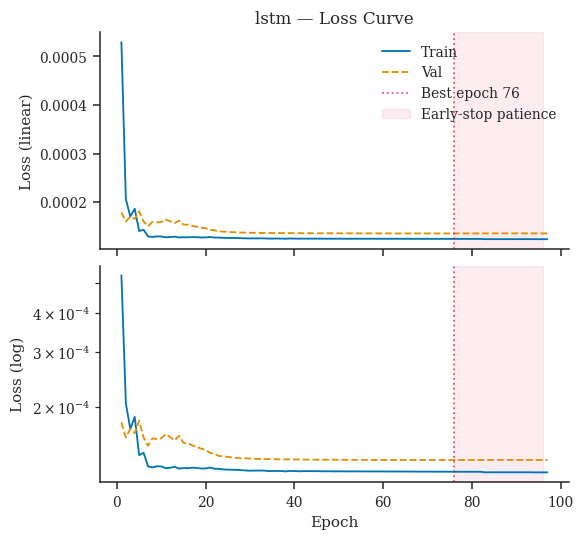

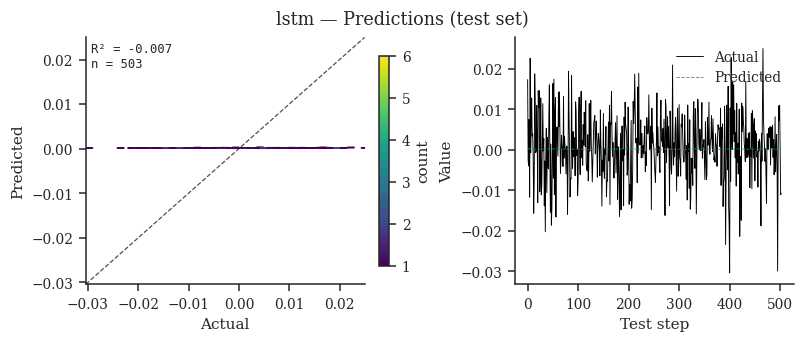

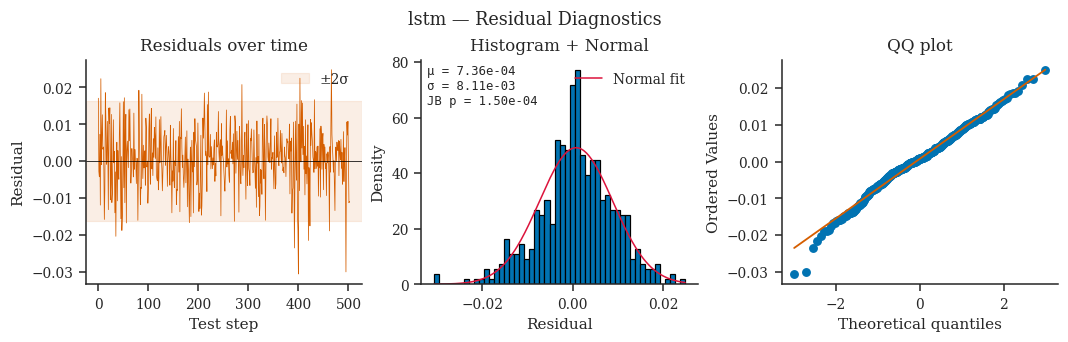

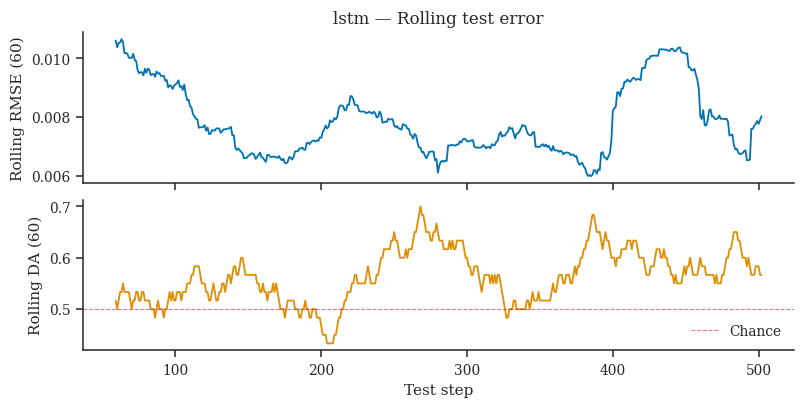

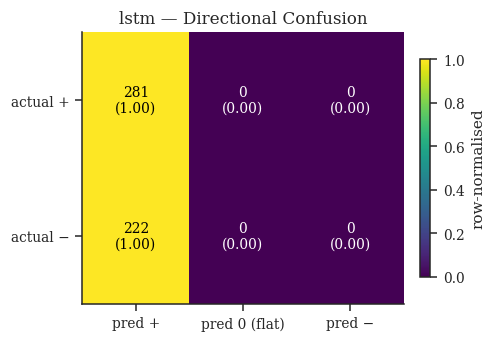

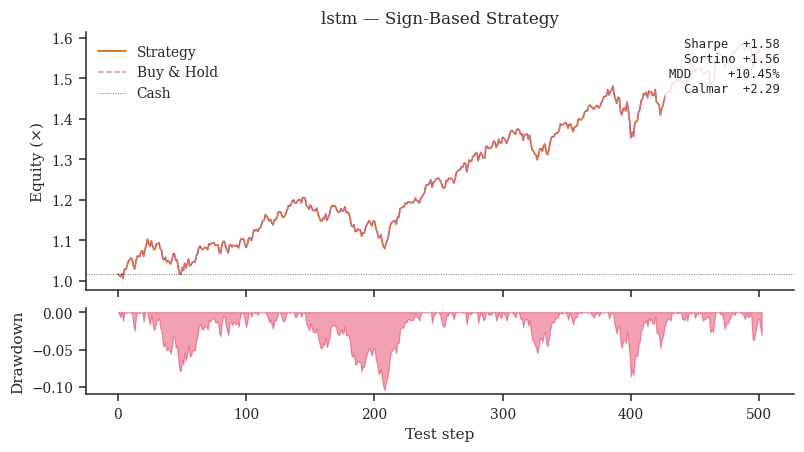

  ✓ lstm: RMSE=0.00815  DA=0.559  Sharpe=+1.575  → results/per_model/lstm


In [ ]:
lstm_config = TrainingConfig(
    epochs=200,
    batch_size=64,
    learning_rate=0.001,
    patience=20,
    tickers=[TICKER],
    start_date=DATA_START,
    end_date=DATA_END,
    aux_tickers=["^VIX", "^TNX"],
    features=[
        "log_return",
        "rolling_volatility_5",
        "rolling_volatility_20",
        "atr_14",
        "vol_premium",
        "momentum_5",
        "momentum_20",
        "rsi_14",
        "macd",
        "macd_signal",
        "bollinger_lower",
        "close_normalized",
        "volume_normalized",
        "vix_level",
        "vix_change",
        "overnight_gap",
        "tnx_level",
        "tnx_change",
    ],
)

lstm_result = train_one("lstm", lstm_config)

19:57:13 | INFO    | src.data.dataset | Splits -> train=2567 val=503 test=503 (seq_len=60, features=14)
19:57:13 | INFO    | src.training.runner | [REAL TRAINING] bilstm on ^GSPC (epochs=200, seed=42)



Training: BILSTM on ^GSPC


19:57:13 | INFO    | src.training.trainer | Epoch 1/200 — train=0.001233 val=0.001819 scale=1.00 lr=1.00e-03
19:57:13 | INFO    | src.training.trainer | Epoch 2/200 — train=0.000560 val=0.000405 scale=1.00 lr=1.00e-03
19:57:14 | INFO    | src.training.trainer | Epoch 3/200 — train=0.000539 val=0.000385 scale=1.00 lr=1.00e-03
19:57:14 | INFO    | src.training.trainer | Epoch 4/200 — train=0.000376 val=0.000355 scale=1.00 lr=1.00e-03
19:57:15 | INFO    | src.training.trainer | Epoch 5/200 — train=0.000290 val=0.000157 scale=1.00 lr=1.00e-03
19:57:15 | INFO    | src.training.trainer | Epoch 6/200 — train=0.000132 val=0.000156 scale=1.00 lr=1.00e-03
19:57:15 | INFO    | src.training.trainer | Epoch 7/200 — train=0.000155 val=0.000157 scale=1.00 lr=1.00e-03
19:57:16 | INFO    | src.training.trainer | Epoch 8/200 — train=0.000125 val=0.000154 scale=1.00 lr=1.00e-03
19:57:16 | INFO    | src.training.trainer | Epoch 9/200 — train=0.000134 val=0.000161 scale=1.00 lr=1.00e-03
19:57:16 | INFO    

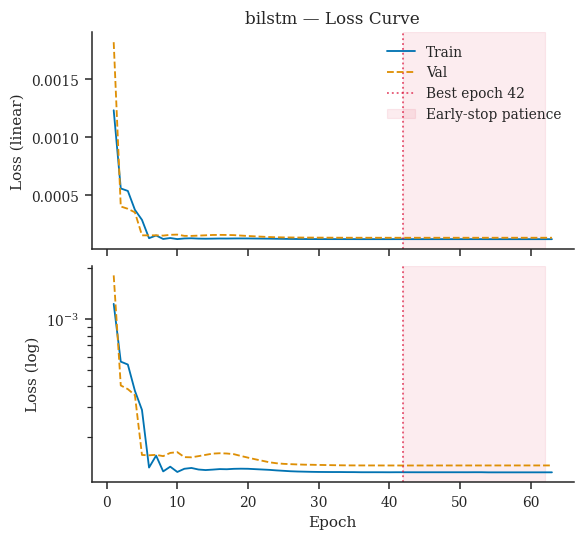

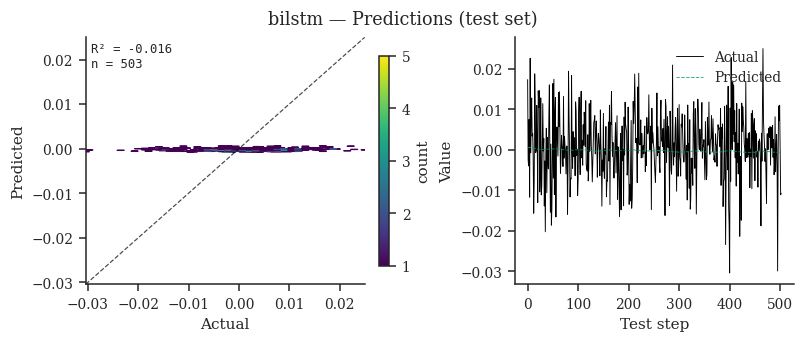

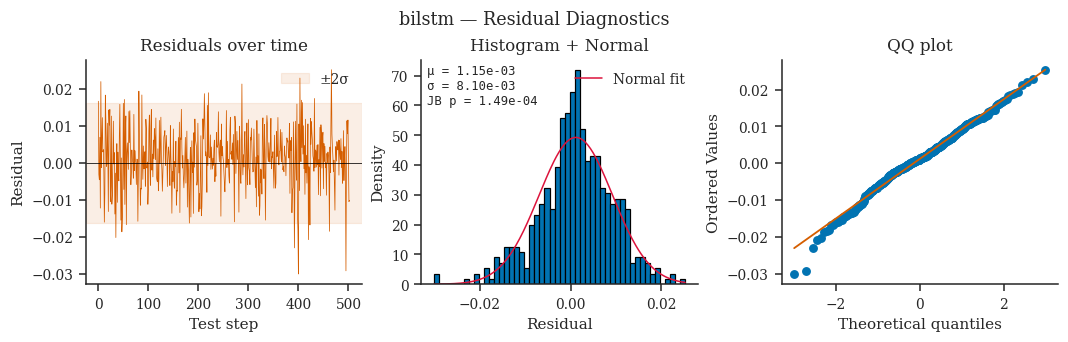

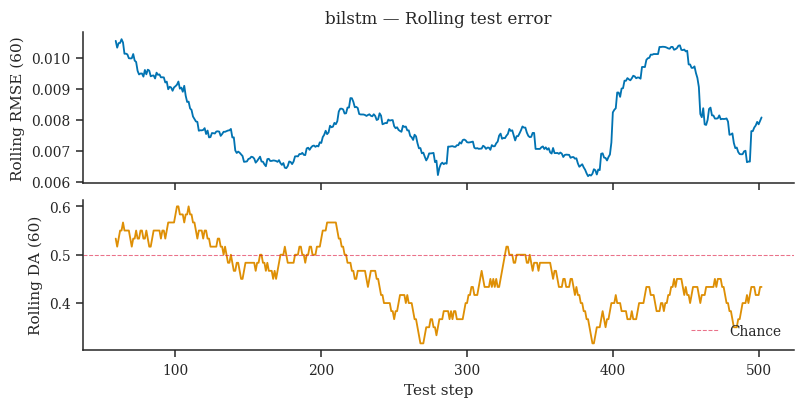

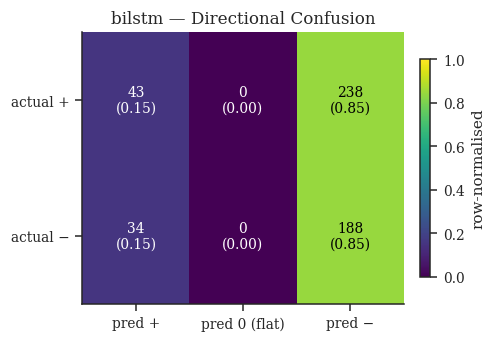

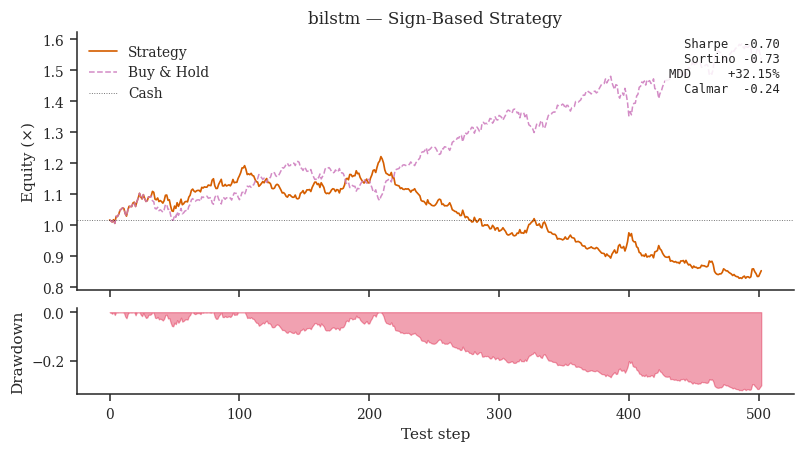

  ✓ bilstm: RMSE=0.00818  DA=0.459  Sharpe=-0.700  → results/per_model/bilstm


In [ ]:
bilstm_config = TrainingConfig(
    epochs=200,
    batch_size=64,
    learning_rate=0.001,
    patience=20,
    tickers=[TICKER],
    start_date=DATA_START,
    end_date=DATA_END,
    aux_tickers=["^VIX", "^TNX"],
    features=[
        "log_return",
        "rolling_volatility_5",
        "rolling_volatility_20",
        "atr_14",
        "vol_premium",
        "momentum_5",
        "momentum_20",
        "rsi_14",
        "macd",
        "macd_signal",
        "bollinger_lower",
        "close_normalized",
        "volume_normalized",
        "vix_level",
        "vix_change",
        "overnight_gap",
        "tnx_level",
        "tnx_change",
    ],
)

bilstm_result = train_one("bilstm", bilstm_config)

In [ ]:
import numpy as np

if lstm_result is not None and bilstm_result is not None:
    lstm_signs   = np.sign(np.asarray(lstm_result.test_preds).ravel())
    bilstm_signs = np.sign(np.asarray(bilstm_result.test_preds).ravel())
    n_test      = len(lstm_signs)
    n_disagree  = int(np.sum(lstm_signs != bilstm_signs))
    pct         = n_disagree / n_test * 100

    print(f"Test samples       : {n_test}")
    print(f"Sign disagreements : {n_disagree} / {n_test}  ({pct:.1f}%)")

    if n_disagree == 0:
        print("IDENTICAL sign vectors — BiLSTM and LSTM make the same directional "
              "call on every test step.")
    else:
        print(f"✓  Models disagree on {n_disagree} steps — architectures are distinguishable.")
        print(f"   Interpretation: ~{100 - pct:.1f}% agreement vs {pct:.1f}% disagreement.")
        if pct > 70:
            print(">70% disagreement with near-equal RMSE is consistent with "
                  "near-zero forecast collapse (opposing sign biases, not meaningful "
                  "directional forecasting by either model).")
else:
    print("Skipped — lstm_result or bilstm_result is None.")

In [ ]:
from src.evaluation.forecast_tests import diebold_mariano

if lstm_result is not None and bilstm_result is not None:
    actual         = np.asarray(lstm_result.test_actual).ravel()
    lstm_preds     = np.asarray(lstm_result.test_preds).ravel()
    bilstm_preds   = np.asarray(bilstm_result.test_preds).ravel()

    errors_lstm   = lstm_preds   - actual
    errors_bilstm = bilstm_preds - actual

    dm_stat, dm_p = diebold_mariano(errors_lstm, errors_bilstm, h=1)

    print(f"Diebold–Mariano statistic : {dm_stat:+.4f}")
    print(f"p-value (two-sided)       : {dm_p:.4f}")
    print()

    if dm_p > 0.05:
        print("→ Fail to reject H0: no significant difference in forecast accuracy (α=0.05).")
    else:
        model_better = "LSTM" if dm_stat < 0 else "BiLSTM"
        print(f"Reject H0 at α=0.05: {model_better} has significantly lower MSE.")

    print(f"\nNote: negative DM stat means LSTM has lower MSE loss.")
    print(f"Consider Harvey–Leybourne–Newbold size correction for n={len(actual)}.")
else:
    print("Skipped — lstm_result or bilstm_result is None.")

In [ ]:
import numpy as np

def _fmt(result, name):
    if result is None:
        return f"{name}: NOT AVAILABLE"
    tm = result.test_metrics
    nan = float('nan')
    return (
        f"{name:>12} | "
        f"{tm.get('rmse', nan):.5f}    "
        f"{tm.get('mae', nan):.5f}   "
        f"{tm.get('r_squared', nan):+.4f}   "
        f"{tm.get('directional_accuracy', nan):.3f}   "
        f"{tm.get('sharpe', nan):+.4f}   "
        f"{tm.get('max_drawdown', nan):.3f}"
    )

print("=" * 90)
print(f"{'Model':>12} | {'RMSE':<12}{'MAE':<12}{'R²':<11}{'DA':<9}{'Sharpe':<11}{'MDD'}")
print("=" * 90)
print(_fmt(lstm_result,   "lstm"))
print(_fmt(bilstm_result, "bilstm"))
print("=" * 90)


In [ ]:
try:
    from google.colab import drive  # noqa: F401  (already mounted above)
    import shutil
    from pathlib import Path

    drive_ckpt = Path("/content/drive/MyDrive/finn_checkpoints")
    ckpt_src = Path("results/checkpoints")
    if ckpt_src.exists():
        drive_ckpt.mkdir(parents=True, exist_ok=True)
        shutil.copytree(ckpt_src, drive_ckpt, dirs_exist_ok=True)
        print(f"✓ Checkpoints backed up to {drive_ckpt}")

    drive_per_model = Path("/content/drive/MyDrive/finn_results/per_model")
    per_model_src = Path("results/per_model")
    if per_model_src.exists():
        drive_per_model.mkdir(parents=True, exist_ok=True)
        shutil.copytree(per_model_src, drive_per_model, dirs_exist_ok=True)
        print(f"✓ Per-model artefacts backed up to {drive_per_model}")

    drive_wf = Path("/content/drive/MyDrive/finn_results/walk_forward")
    wf_src = Path("results/walk_forward")
    if wf_src.exists():
        drive_wf.mkdir(parents=True, exist_ok=True)
        shutil.copytree(wf_src, drive_wf, dirs_exist_ok=True)
        print(f"✓ Walk-forward artefacts backed up to {drive_wf}")
except ImportError:
    print("Not running in Colab — Drive backup skipped")